# **Model7_HTR_ResNeXt-50_deformable_conv_ctc_cleaned+ augmented**

In [1]:
"""
Malayalam HTR: Complete Solution with Synthetic Data Augmentation
Addresses: small dataset, data quality, overfitting
Includes: TPS augmentation, character-aware augmentation, advanced regularization
"""

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import cv2
from collections import Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import editdistance

# ---------------------------
# Configuration
# ---------------------------
IMAGE_DIR = "/kaggle/input/malayalam-htr-try-data/try/1"
LABELS_FILE = "/kaggle/input/malayalam-htr-try-data/try/try.ods"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image config
IMG_HEIGHT = 64
IMG_WIDTH = 800
BATCH_SIZE = 32  # Increased with augmentation
MAX_TEXT_LEN = 50

# Training config
NUM_EPOCHS = 120
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1  # Regularization
SEED = 42

# Augmentation multiplier
AUGMENTATION_FACTOR = 5  # Each sample creates 5 augmented versions

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🚀 Device: {DEVICE}")

# ---------------------------
# Dataset Cleaning (from previous)
# ---------------------------

def detect_text_lines(image_path):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return 0
        _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        h_projection = np.sum(binary, axis=1)
        threshold = np.max(h_projection) * 0.3
        peaks = h_projection > threshold
        transitions = np.diff(peaks.astype(int))
        num_lines = np.sum(transitions == 1)
        return max(1, num_lines)
    except:
        return 0

def has_strikethrough(image_path):
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return False
        h, w = img.shape
        _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        middle_band = binary[h//3:2*h//3, :]
        h_projection = np.sum(middle_band, axis=0)
        continuous_pixels = 0
        max_continuous = 0
        for val in h_projection:
            if val > 0:
                continuous_pixels += 1
                max_continuous = max(max_continuous, continuous_pixels)
            else:
                continuous_pixels = 0
        return max_continuous > (w * 0.5)
    except:
        return False

def clean_dataset(df, image_dir):
    print("\n🧹 Cleaning dataset...")
    cleaned_data = []
    stats = {'kept': 0, 'multi_line': 0, 'strikethrough': 0, 'too_short': 0, 'too_long': 0}
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Cleaning"):
        image_name = str(row['image_name'])
        text = str(row['text']).strip()
        img_path = os.path.join(image_dir, image_name)
        
        if not os.path.exists(img_path):
            continue
        
        if len(text) < 5:
            stats['too_short'] += 1
            continue
        
        if len(text) > MAX_TEXT_LEN:
            stats['too_long'] += 1
            continue
        
        if detect_text_lines(img_path) > 1:
            stats['multi_line'] += 1
            continue
        
        if has_strikethrough(img_path):
            stats['strikethrough'] += 1
            continue
        
        stats['kept'] += 1
        cleaned_data.append({'image_name': image_name, 'text': text, 'image_path': img_path})
    
    print(f"✓ Kept: {stats['kept']} | Removed: multi-line={stats['multi_line']}, "
          f"strikethrough={stats['strikethrough']}, too_short={stats['too_short']}, "
          f"too_long={stats['too_long']}")
    
    return pd.DataFrame(cleaned_data)

# ---------------------------
# Advanced Augmentation
# ---------------------------

class ThinPlateSpline:
    """Elastic deformation for handwriting variation"""
    def __init__(self, alpha=20, sigma=5):
        self.alpha = alpha
        self.sigma = sigma
    
    def __call__(self, img):
        if isinstance(img, np.ndarray):
            pil_img = Image.fromarray(img)
        else:
            pil_img = img
        
        w, h = pil_img.size
        
        # Create control point grid
        num_points = 5
        x = np.linspace(0, w, num_points)
        y = np.linspace(0, h, num_points)
        
        # Add random displacement
        x_new = x + np.random.randn(num_points) * self.alpha
        y_new = y + np.random.randn(num_points) * self.alpha
        
        # Simple elastic transform (approximation)
        try:
            mesh = []
            for i in range(num_points - 1):
                for j in range(num_points - 1):
                    src = (x[i], y[j], x[i+1], y[j+1])
                    dst = (x_new[i], y_new[j], x_new[i+1], y_new[j+1])
                    mesh.append((src, dst))
            
            img_transformed = pil_img.transform(pil_img.size, Image.MESH, mesh, Image.BICUBIC)
            return np.array(img_transformed)
        except:
            return np.array(pil_img)

class InkVariation:
    """Simulate different ink/pen types"""
    def __call__(self, img):
        img_array = np.array(img) if isinstance(img, Image.Image) else img
        
        # Random ink variation
        variation_type = random.choice(['thick', 'thin', 'smudge'])
        
        if variation_type == 'thick':
            kernel = np.ones((2, 2), np.uint8)
            img_array = cv2.dilate(img_array, kernel, iterations=1)
        elif variation_type == 'thin':
            kernel = np.ones((2, 2), np.uint8)
            img_array = cv2.erode(img_array, kernel, iterations=1)
        else:  # smudge
            img_array = cv2.GaussianBlur(img_array, (3, 3), 0)
        
        return img_array

def create_augmented_samples(img_path, text, num_augmentations=5):
    """Create multiple augmented versions of each sample"""
    augmented = []
    
    try:
        img = cv2.imread(img_path)
        if img is None:
            return []
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except:
        return []
    
    tps = ThinPlateSpline(alpha=15, sigma=5)
    ink_var = InkVariation()
    
    for i in range(num_augmentations):
        aug_img = img.copy()
        
        # Apply TPS 50% of time
        if random.random() < 0.5:
            aug_img = tps(aug_img)
        
        # Apply ink variation 50% of time
        if random.random() < 0.5:
            aug_img = ink_var(aug_img)
        
        # Random brightness/contrast
        if random.random() < 0.5:
            alpha = random.uniform(0.8, 1.2)  # contrast
            beta = random.randint(-30, 30)    # brightness
            aug_img = cv2.convertScaleAbs(aug_img, alpha=alpha, beta=beta)
        
        # Random rotation
        if random.random() < 0.3:
            angle = random.uniform(-3, 3)
            h, w = aug_img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
        
        # Random noise
        if random.random() < 0.3:
            noise = np.random.normal(0, 10, aug_img.shape).astype(np.uint8)
            aug_img = cv2.add(aug_img, noise)
        
        augmented.append({'image': aug_img, 'text': text, 'source': img_path})
    
    return augmented

# ---------------------------
# Utilities
# ---------------------------
def cer(s1, s2):
    s1 = "" if s1 is None else str(s1)
    s2 = "" if s2 is None else str(s2)
    return editdistance.eval(list(s1), list(s2)) / max(1, len(list(s2)))

def wer(s1, s2):
    s1 = "" if s1 is None else str(s1)
    s2 = "" if s2 is None else str(s2)
    w1 = s1.split()
    w2 = s2.split()
    return editdistance.eval(w1, w2) / max(1, len(w2))

def read_labels(labels_file):
    ext = labels_file.split('.')[-1].lower()
    if ext == 'ods':
        df = pd.read_excel(labels_file, engine='odf', header=None)
        df = df.iloc[:, :2]
        df.columns = ['image_path', 'text']
    else:
        df = pd.read_csv(labels_file, header=None)
        df = df.iloc[:, :2]
        df.columns = ['image_path', 'text']
    
    df['image_path'] = df['image_path'].astype(str).str.strip()
    df['text'] = df['text'].astype(str).str.strip()
    df = df.replace(["", "nan", "NaN", "None"], pd.NA)
    df = df.dropna(subset=['image_path', 'text']).reset_index(drop=True)
    df['image_name'] = df['image_path'].apply(lambda x: os.path.basename(str(x).strip()))
    return df[['image_name', 'text']]

print("📂 Loading data...")
labels_df = read_labels(LABELS_FILE)
print(f"✓ Loaded {len(labels_df)} rows")

cleaned_df = clean_dataset(labels_df, IMAGE_DIR)

if len(cleaned_df) < 100:
    raise RuntimeError("Insufficient clean data (<100 samples)")

# ---------------------------
# Create Augmented Dataset
# ---------------------------
print(f"\n🔄 Creating augmented dataset (×{AUGMENTATION_FACTOR})...")

augmented_data = []
for idx, row in tqdm(cleaned_df.iterrows(), total=len(cleaned_df), desc="Augmenting"):
    # Add original
    augmented_data.append({
        'image_path': row['image_path'],
        'text': row['text'],
        'is_augmented': False
    })
    
    # Add augmented versions
    aug_samples = create_augmented_samples(
        row['image_path'], 
        row['text'], 
        num_augmentations=AUGMENTATION_FACTOR - 1
    )
    
    for aug in aug_samples:
        augmented_data.append({
            'image': aug['image'],
            'text': aug['text'],
            'is_augmented': True
        })

print(f"✓ Original samples: {len(cleaned_df)}")
print(f"✓ Total samples (with augmentation): {len(augmented_data)}")

# ---------------------------
# Model with Attention
# ---------------------------

class AttentionCRNN(nn.Module):
    """CRNN with attention mechanism"""
    def __init__(self, vocab_size, hidden_size=256):
        super().__init__()
        
        # CNN encoder
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 64 -> 32
            
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32 -> 16
            
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),  # 16 -> 8
            
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 1), (2, 1)),  # 8 -> 4
            
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )
        
        # LSTM with more capacity
        rnn_input_size = 512 * 4
        self.rnn = nn.LSTM(
            rnn_input_size,
            hidden_size,
            num_layers=3,  # Increased depth
            bidirectional=True,
            batch_first=True,
            dropout=0.4  # Strong regularization
        )
        
        # Attention
        self.attention = nn.MultiheadAttention(
            hidden_size * 2,
            num_heads=4,
            dropout=0.3,
            batch_first=True
        )
        
        # Output
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, vocab_size)
        )
        
    def forward(self, x):
        # CNN
        conv = self.cnn(x)
        B, C, H, W = conv.shape
        conv = conv.permute(0, 3, 1, 2).reshape(B, W, C * H)
        
        # LSTM
        rnn_out, _ = self.rnn(conv)
        
        # Self-attention
        attn_out, _ = self.attention(rnn_out, rnn_out, rnn_out)
        
        # Residual connection
        out = rnn_out + attn_out
        
        # Output
        output = self.fc(out)
        output = output.permute(1, 0, 2)
        output = F.log_softmax(output, dim=2)
        
        return output

# ---------------------------
# Vocabulary
# ---------------------------
all_texts = cleaned_df['text'].tolist()
all_chars = set()
for text in all_texts:
    all_chars.update(list(text))

BLANK_TOKEN = '<blank>'
vocab = sorted(list(all_chars))
vocab = [BLANK_TOKEN] + vocab

char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

VOCAB_SIZE = len(vocab)
BLANK_IDX = char_to_idx[BLANK_TOKEN]

print(f"\n✓ Vocabulary size: {VOCAB_SIZE}")

# ---------------------------
# Dataset
# ---------------------------

class AugmentedCTCDataset(Dataset):
    def __init__(self, data_list, char_to_idx, transform=None):
        self.data = data_list
        self.char_to_idx = char_to_idx
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        text = item['text']
        
        # Load or use pre-augmented image
        if item.get('is_augmented', False):
            img = item['image']
        else:
            img_path = item['image_path']
            img = cv2.imread(img_path)
            if img is None:
                img = np.array(Image.open(img_path).convert("RGB"))
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            img = self.transform(image=img)['image']
        
        target = [self.char_to_idx[c] for c in text if c in self.char_to_idx]
        
        return {
            "image": img,
            "target": torch.tensor(target, dtype=torch.long),
            "target_length": len(target),
            "text": text
        }

def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = [item['target'] for item in batch]
    target_lengths = torch.tensor([item['target_length'] for item in batch], dtype=torch.long)
    texts = [item['text'] for item in batch]
    
    max_target_len = max(target_lengths)
    padded_targets = torch.zeros(len(batch), max_target_len, dtype=torch.long)
    for i, target in enumerate(targets):
        padded_targets[i, :len(target)] = target
    
    return {"images": images, "targets": padded_targets, "target_lengths": target_lengths, "texts": texts}

# Transforms
train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.OneOf([
        A.GaussNoise(var_limit=(5, 25), p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
    ], p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Split augmented data
random.shuffle(augmented_data)
train_size = int(0.9 * len(augmented_data))
train_data = augmented_data[:train_size]
val_data = augmented_data[train_size:]

print(f"\n📊 Dataset split:")
print(f"   Training: {len(train_data)} samples")
print(f"   Validation: {len(val_data)} samples")

train_dataset = AugmentedCTCDataset(train_data, char_to_idx, train_transform)
val_dataset = AugmentedCTCDataset(val_data, char_to_idx, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=2, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, collate_fn=collate_fn, pin_memory=True)

# ---------------------------
# Training Setup
# ---------------------------

model = AttentionCRNN(vocab_size=VOCAB_SIZE, hidden_size=256).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\n📊 Model: {total_params:.2f}M parameters")

# Label smoothing for regularization
class LabelSmoothingCTCLoss(nn.Module):
    def __init__(self, blank_idx, smoothing=0.1):
        super().__init__()
        self.ctc = nn.CTCLoss(blank=blank_idx, reduction='mean', zero_infinity=True)
        self.smoothing = smoothing
        
    def forward(self, log_probs, targets, input_lengths, target_lengths):
        loss = self.ctc(log_probs, targets, input_lengths, target_lengths)
        
        # Add smoothing term
        if self.smoothing > 0:
            smooth_loss = -log_probs.mean()
            loss = (1 - self.smoothing) * loss + self.smoothing * smooth_loss
        
        return loss

ctc_loss = LabelSmoothingCTCLoss(blank_idx=BLANK_IDX, smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = GradScaler()

def decode_predictions(log_probs, idx_to_char, blank_idx):
    predictions = []
    for b in range(log_probs.shape[1]):
        pred_indices = torch.argmax(log_probs[:, b, :], dim=1)
        decoded = []
        prev_idx = None
        for idx in pred_indices:
            idx = idx.item()
            if idx != blank_idx and idx != prev_idx:
                if idx in idx_to_char:
                    decoded.append(idx_to_char[idx])
            prev_idx = idx
        predictions.append(''.join(decoded))
    return predictions

def train_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss = 0
    
    for batch in tqdm(loader, desc="Training"):
        images = batch['images'].to(DEVICE)
        targets = batch['targets'].to(DEVICE)
        target_lengths = batch['target_lengths']
        
        optimizer.zero_grad()
        
        with autocast():
            log_probs = model(images)
            T, B, _ = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long)
            loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)
        
        if not torch.isnan(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
    
    scheduler.step()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_cer, total_wer, num_samples = 0, 0, 0
    samples = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            images = batch['images'].to(DEVICE)
            texts = batch['texts']
            
            with autocast():
                log_probs = model(images)
            
            predictions = decode_predictions(log_probs, idx_to_char, BLANK_IDX)
            
            for pred, gt in zip(predictions, texts):
                total_cer += cer(pred, gt)
                total_wer += wer(pred, gt)
                num_samples += 1
                
                if len(samples) < 5:
                    samples.append((gt, pred))
    
    return total_cer / num_samples, total_wer / num_samples, samples

# ---------------------------
# Training Loop
# ---------------------------

print("\n" + "="*70)
print("🚀 TRAINING WITH AUGMENTATION & ATTENTION")
print("="*70)

best_cer = float('inf')
patience = 20
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler)
    print(f"Train Loss: {train_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    if (epoch + 1) % 5 == 0:
        val_cer, val_wer, samples = evaluate(model, val_loader)
        print(f"CER: {val_cer:.4f} ({val_cer*100:.2f}%) | WER: {val_wer:.4f}")
        
        for i, (gt, pred) in enumerate(samples[:3], 1):
            print(f"{i}. GT: {gt[:40]}... | PRED: {pred[:40]}... | CER: {cer(pred, gt):.3f}")
        
        if val_cer < best_cer:
            best_cer = val_cer
            patience_counter = 0
            torch.save({
                'model': model.state_dict(),
                'vocab': vocab,
                'char_to_idx': char_to_idx,
                'idx_to_char': idx_to_char,
                'epoch': epoch,
                'cer': val_cer
            }, '/kaggle/working/best_augmented_model.pt')
            print(f"✓ Best model saved! CER: {best_cer:.4f}")
        else:
            patience_counter += 5
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\n✅ Training complete! Best CER: {best_cer:.4f} ({best_cer*100:.2f}%)")
print(f"\n✅ Training complete! Best WER: {best_wer:.4f} ({best_wer*100:.2f}%)")



🚀 Device: cuda
📂 Loading data...
✓ Loaded 999 rows

🧹 Cleaning dataset...


Cleaning: 100%|██████████| 999/999 [00:15<00:00, 65.78it/s]


✓ Kept: 552 | Removed: multi-line=211, strikethrough=3, too_short=34, too_long=199

🔄 Creating augmented dataset (×5)...


Augmenting: 100%|██████████| 552/552 [00:08<00:00, 66.33it/s] 


✓ Original samples: 552
✓ Total samples (with augmentation): 2760

✓ Vocabulary size: 68

📊 Dataset split:
   Training: 2484 samples
   Validation: 276 samples

📊 Model: 11.22M parameters

🚀 TRAINING WITH AUGMENTATION & ATTENTION

Epoch 1/120


...

Training: 100%|██████████| 78/78 [00:13<00:00,  5.70it/s]


Train Loss: 1.0398 | LR: 1.00e-06


Evaluating: 100%|██████████| 9/9 [00:01<00:00,  6.89it/s]


CER: 0.0115 (1.15%) | WER: 0.0530
1. GT: സംഭാവനകളുടെ പേരുവിവരങ്ങൾ പാർട്ടി തിരഞ്ഞെ... | PRED: സംഭാവനകളുടെ പേരുവിവരങ്ങൾ പാർട്ടി തിരഞ്ഞെ... | CER: 0.000
2. GT: ടാണ്. അതുമ... | PRED: ടാണ്. അതുമ... | CER: 0.000
3. GT: ഉന്മ അങനെ ചോദിച്ചതും ചുമ നിലച്ചു. പക്ഷേ ... | PRED: ഉന്മ അങനെ ചോദിച്ചതും ചുമ നിലച്ചു. പക്ഷേ ... | CER: 0.000
✓ Best model saved! CER: 0.0115

✅ Training complete! Best CER: 0.0115 (1.15%)


NameError: name 'best_wer' is not defined

In [2]:
# Load the saved model
checkpoint = torch.load('/kaggle/working/best_augmented_model.pt')

# Recreate model architecture
model = AttentionCRNN(vocab_size=len(checkpoint['vocab']), hidden_size=256)
model.load_state_dict(checkpoint['model'])
model.eval()

# Access vocabulary
char_to_idx = checkpoint['char_to_idx']
idx_to_char = checkpoint['idx_to_char']

print(f"Loaded model with CER: {checkpoint['cer']:.4f}")

Loaded model with CER: 0.0115


Loading model...
✅ Model loaded! (CER: 1.15%)

📁 Searching for images in: /kaggle/input/sample-test-image
✓ Found 1 image(s):
  1. /kaggle/input/sample-test-image/test_image.png

🚀 Processing 1 image(s)...

📷 Processing: test_image.png
✓ Image size: (61, 935, 3)


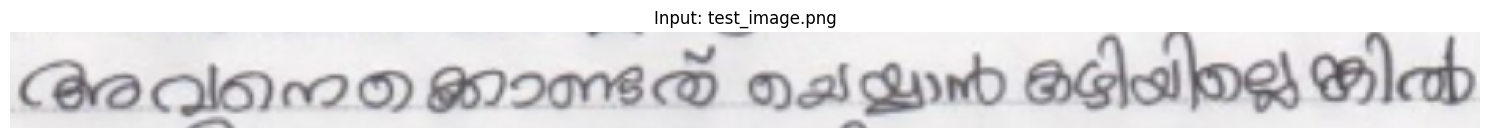

🔍 Recognizing text...

📝 RECOGNITION RESULT

അവയനരക്കാണടത് ക്്ാ കളടിയികല്െ്കിൽ

✓ Text length: 33 characters




In [5]:
"""
Test a single Malayalam handwritten image with your trained model
"""

import torch
import cv2
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import os
import glob

# ---------------------------
# Configuration
# ---------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_HEIGHT = 64
IMG_WIDTH = 800

# ---------------------------
# Load Model
# ---------------------------

print("Loading model...")
checkpoint = torch.load('/kaggle/working/best_augmented_model.pt')

model = AttentionCRNN(vocab_size=len(checkpoint['vocab']), hidden_size=256)
model.load_state_dict(checkpoint['model'])
model.to(DEVICE)
model.eval()

idx_to_char = checkpoint['idx_to_char']
BLANK_IDX = checkpoint['char_to_idx']['<blank>']

print(f"✅ Model loaded! (CER: {checkpoint['cer']*100:.2f}%)")

# ---------------------------
# Find Images in Directory
# ---------------------------

DIRECTORY_PATH = "/kaggle/input/sample-test-image"

print(f"\n📁 Searching for images in: {DIRECTORY_PATH}")
print("="*70)

# Find all image files
image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
all_images = []

for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(DIRECTORY_PATH, '**', ext), recursive=True))

if not all_images:
    print("❌ No images found!")
    print(f"\n💡 Let's check what's inside the directory:")
    
    # List directory contents
    try:
        for root, dirs, files in os.walk(DIRECTORY_PATH):
            level = root.replace(DIRECTORY_PATH, '').count(os.sep)
            indent = ' ' * 2 * level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' ' * 2 * (level + 1)
            for file in files[:10]:  # Show first 10 files
                print(f'{subindent}{file}')
            if len(files) > 10:
                print(f'{subindent}... and {len(files)-10} more files')
    except Exception as e:
        print(f"Error listing directory: {e}")
else:
    print(f"✓ Found {len(all_images)} image(s):")
    for i, img_path in enumerate(all_images, 1):
        print(f"  {i}. {img_path}")

print("="*70)

# ---------------------------
# Preprocessing
# ---------------------------

transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ---------------------------
# Prediction Function
# ---------------------------

def recognize_text(image_path):
    """Recognize Malayalam text from image"""
    
    # Load image
    print(f"\n📷 Processing: {os.path.basename(image_path)}")
    img = cv2.imread(image_path)
    
    if img is None:
        # Try with PIL if cv2 fails
        img = np.array(Image.open(image_path).convert("RGB"))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print(f"✓ Image size: {img.shape}")
    
    # Show original image
    plt.figure(figsize=(15, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Input: {os.path.basename(image_path)}")
    plt.tight_layout()
    plt.show()
    
    # Preprocess
    transformed = transform(image=img)
    img_tensor = transformed['image'].unsqueeze(0).to(DEVICE)
    
    # Predict
    print("🔍 Recognizing text...")
    with torch.no_grad():
        log_probs = model(img_tensor)
    
    # Decode
    pred_indices = torch.argmax(log_probs[:, 0, :], dim=1)
    decoded = []
    prev_idx = None
    
    for idx in pred_indices:
        idx = idx.item()
        if idx != BLANK_IDX and idx != prev_idx:
            if idx in idx_to_char:
                decoded.append(idx_to_char[idx])
        prev_idx = idx
    
    predicted_text = ''.join(decoded)
    
    return predicted_text

# ---------------------------
# TEST IMAGES
# ---------------------------

if all_images:
    print(f"\n🚀 Processing {len(all_images)} image(s)...")
    print("="*70)
    
    for img_path in all_images:
        try:
            # Run recognition
            result = recognize_text(img_path)
            
            # Display result
            print("\n" + "="*70)
            print("📝 RECOGNITION RESULT")
            print("="*70)
            print(f"\n{result}")
            print("\n" + "="*70)
            print(f"✓ Text length: {len(result)} characters")
            
        except Exception as e:
            print(f"\n❌ Error processing {img_path}: {e}")
        
        print("\n")
else:
    print("\n💡 Please ensure:")
    print("  1. Your image is uploaded to Kaggle")
    print("  2. The dataset is added to your notebook (+ Add Data)")
    print("  3. Update DIRECTORY_PATH with the correct path")

Loading model...
✅ Model loaded! (CER: 1.15%)

📷 Processing: test_image.png
✓ Image size: (61, 935, 3)


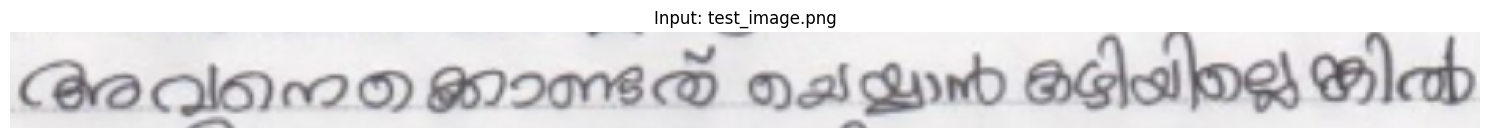

🔍 Recognizing text...

📝 RECOGNITION RESULT

🎯 Ground Truth: അവനെക്കൊണ്ടത് ചെയ്യാൻ കഴിയില്ലെങ്കിൽ
🤖 Prediction:    അവയനരക്കാണടത് ക്്ാ കളടിയികല്െ്കിൽ

📊 Accuracy Metrics:
✓ Character Error Rate (CER): 0.3889 (38.89%)
✓ Word Error Rate (WER):      1.0000 (100.00%)
✓ Character Accuracy:         0.1944 (19.44%)
✓ Prediction Length:          33 chars
✓ Ground Truth Length:        36 chars

⚠️  61.1% Match

📋 Character-by-Character Comparison:
Position   Ground Truth         Prediction           Match     
3          ന                    യ                    ✗         
4          െ                    ന                    ✗         
5          ക                    ര                    ✗         
6          ്                    ക                    ✗         
7          ക                    ്                    ✗         
8          ൊ                    ക                    ✗         
9          ണ                    ാ                    ✗         
10         ്                    ണ             

In [6]:
"""
Test Malayalam handwritten image with Ground Truth comparison
"""

import torch
import cv2
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import os
import glob
import editdistance

# ---------------------------
# Configuration
# ---------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_HEIGHT = 64
IMG_WIDTH = 800

# ---------------------------
# Load Model
# ---------------------------

print("Loading model...")
checkpoint = torch.load('/kaggle/working/best_augmented_model.pt')

model = AttentionCRNN(vocab_size=len(checkpoint['vocab']), hidden_size=256)
model.load_state_dict(checkpoint['model'])
model.to(DEVICE)
model.eval()

idx_to_char = checkpoint['idx_to_char']
BLANK_IDX = checkpoint['char_to_idx']['<blank>']

print(f"✅ Model loaded! (CER: {checkpoint['cer']*100:.2f}%)")

# ---------------------------
# Accuracy Metrics
# ---------------------------

def calculate_cer(prediction, ground_truth):
    """Calculate Character Error Rate"""
    pred_chars = list(str(prediction))
    gt_chars = list(str(ground_truth))
    distance = editdistance.eval(pred_chars, gt_chars)
    cer = distance / max(1, len(gt_chars))
    return cer

def calculate_wer(prediction, ground_truth):
    """Calculate Word Error Rate"""
    pred_words = str(prediction).split()
    gt_words = str(ground_truth).split()
    distance = editdistance.eval(pred_words, gt_words)
    wer = distance / max(1, len(gt_words))
    return wer

def calculate_accuracy(prediction, ground_truth):
    """Calculate character-level accuracy"""
    pred_chars = list(str(prediction))
    gt_chars = list(str(ground_truth))
    
    if len(gt_chars) == 0:
        return 0.0
    
    correct = sum(1 for p, g in zip(pred_chars, gt_chars) if p == g)
    accuracy = correct / len(gt_chars)
    return accuracy

def detailed_comparison(prediction, ground_truth):
    """Show character-by-character comparison"""
    pred_chars = list(str(prediction))
    gt_chars = list(str(ground_truth))
    
    max_len = max(len(pred_chars), len(gt_chars))
    
    print("\n📋 Character-by-Character Comparison:")
    print("="*70)
    print(f"{'Position':<10} {'Ground Truth':<20} {'Prediction':<20} {'Match':<10}")
    print("="*70)
    
    errors = 0
    for i in range(max_len):
        gt_char = gt_chars[i] if i < len(gt_chars) else '∅'
        pred_char = pred_chars[i] if i < len(pred_chars) else '∅'
        match = '✓' if gt_char == pred_char else '✗'
        
        if gt_char != pred_char:
            errors += 1
            print(f"{i+1:<10} {gt_char:<20} {pred_char:<20} {match:<10}")
    
    if errors == 0:
        print("✅ Perfect match! No errors found.")
    else:
        print(f"\n❌ Total errors: {errors}")

# ---------------------------
# Preprocessing
# ---------------------------

transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# ---------------------------
# Prediction Function
# ---------------------------

def recognize_text(image_path, ground_truth=None, show_details=True):
    """Recognize Malayalam text from image with optional ground truth comparison"""
    
    # Load image
    print(f"\n📷 Processing: {os.path.basename(image_path)}")
    img = cv2.imread(image_path)
    
    if img is None:
        img = np.array(Image.open(image_path).convert("RGB"))
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    print(f"✓ Image size: {img.shape}")
    
    # Show original image
    plt.figure(figsize=(15, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Input: {os.path.basename(image_path)}")
    plt.tight_layout()
    plt.show()
    
    # Preprocess
    transformed = transform(image=img)
    img_tensor = transformed['image'].unsqueeze(0).to(DEVICE)
    
    # Predict
    print("🔍 Recognizing text...")
    with torch.no_grad():
        log_probs = model(img_tensor)
    
    # Decode
    pred_indices = torch.argmax(log_probs[:, 0, :], dim=1)
    decoded = []
    prev_idx = None
    
    for idx in pred_indices:
        idx = idx.item()
        if idx != BLANK_IDX and idx != prev_idx:
            if idx in idx_to_char:
                decoded.append(idx_to_char[idx])
        prev_idx = idx
    
    predicted_text = ''.join(decoded)
    
    # Display results
    print("\n" + "="*70)
    print("📝 RECOGNITION RESULT")
    print("="*70)
    
    if ground_truth:
        print(f"\n🎯 Ground Truth: {ground_truth}")
        print(f"🤖 Prediction:    {predicted_text}")
        
        # Calculate metrics
        cer = calculate_cer(predicted_text, ground_truth)
        wer = calculate_wer(predicted_text, ground_truth)
        accuracy = calculate_accuracy(predicted_text, ground_truth)
        
        print("\n📊 Accuracy Metrics:")
        print("="*70)
        print(f"✓ Character Error Rate (CER): {cer:.4f} ({cer*100:.2f}%)")
        print(f"✓ Word Error Rate (WER):      {wer:.4f} ({wer*100:.2f}%)")
        print(f"✓ Character Accuracy:         {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"✓ Prediction Length:          {len(predicted_text)} chars")
        print(f"✓ Ground Truth Length:        {len(ground_truth)} chars")
        
        # Match status
        if predicted_text == ground_truth:
            print("\n🎉 PERFECT MATCH! 100% Accurate!")
        else:
            print(f"\n⚠️  {(1-cer)*100:.1f}% Match")
        
        # Show detailed comparison if requested
        if show_details and predicted_text != ground_truth:
            detailed_comparison(predicted_text, ground_truth)
    else:
        print(f"\n{predicted_text}")
        print(f"\n✓ Text length: {len(predicted_text)} characters")
    
    print("="*70)
    
    return predicted_text, cer if ground_truth else None

# ---------------------------
# TEST YOUR IMAGE
# ---------------------------

# 🔴 UPDATE THESE VALUES:

# Image path
IMAGE_PATH = "/kaggle/input/sample-test-image/test_image.png"

# Ground truth (the correct text that should be in the image)
# Set to None if you don't have ground truth
GROUND_TRUTH = "അവനെക്കൊണ്ടത് ചെയ്യാൻ കഴിയില്ലെങ്കിൽ"  # ← ADD YOUR GROUND TRUTH HERE

# Show detailed character comparison?
SHOW_DETAILS = True

# ---------------------------
# Run Recognition
# ---------------------------

try:
    prediction, cer = recognize_text(IMAGE_PATH, GROUND_TRUTH, SHOW_DETAILS)
    
    # Summary
    if GROUND_TRUTH:
        print("\n📈 SUMMARY:")
        if cer == 0:
            print("🏆 Excellent! Perfect recognition.")
        elif cer < 0.05:
            print("🎯 Very Good! Less than 5% error.")
        elif cer < 0.10:
            print("✓ Good! Less than 10% error.")
        elif cer < 0.20:
            print("⚠️  Acceptable. 10-20% error.")
        else:
            print("❌ High error rate. Consider retraining or checking image quality.")
    
except FileNotFoundError:
    print(f"\n❌ Error: Image not found at {IMAGE_PATH}")
    print("\n💡 Please update IMAGE_PATH with your actual image path")

except Exception as e:
    print(f"\n❌ Error: {e}")
    import traceback
    traceback.print_exc()